<a href="https://colab.research.google.com/github/hasmalee/aeropinn/blob/main/best_aoa_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AeroPINN-X — Best AoA Surrogate Training
## Train a PINN surrogate that covers a full angle-of-attack range, then sweep to find the best AoA.

**What this notebook does:**
1. Mounts Google Drive (Colab) or uses a local path.
2. Loads your airfoil `.dat` file.
3. Trains a PINN surrogate over `alpha_min → alpha_max` (Gap 22 — multi-alpha surrogate mode).
4. Runs `aoa_sweep()` to evaluate L/D, CL, CD at each alpha.
5. Plots the objective vs AoA curve.
6. Saves the checkpoint as `best_aoa_surrogate.pt` ready for the app.

---
**Where to save the checkpoint:**
```
aeropinn_app/backend/models/best_aoa_surrogate.pt
```
Or set `MODEL_CHECKPOINT=models/best_aoa_surrogate.pt` in your `.env`.


In [1]:
# ═══════════════════════════════════════════════════════════════
#  CELL 1 — Environment Setup
# ═══════════════════════════════════════════════════════════════

import os, sys
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # ── EDIT this path to where your project lives on Drive ──
    PROJECT_ROOT = '/content/drive/MyDrive/AeroPINN_X'   # <-- CHANGE
    sys.path.insert(0, PROJECT_ROOT)
    sys.path.insert(0, os.path.join(PROJECT_ROOT, 'AeroPINN_X', 'model'))
    sys.path.insert(0, os.path.join(PROJECT_ROOT, 'AeroPINN_X', 'data'))
    sys.path.insert(0, os.path.join(PROJECT_ROOT, 'AeroPINN_X', 'geometry'))
    sys.path.insert(0, os.path.join(PROJECT_ROOT, 'AeroPINN_X', 'train'))
    sys.path.insert(0, os.path.join(PROJECT_ROOT, 'AeroPINN_X', 'postprocess'))
else:
    # Local run — set PROJECT_ROOT to where your AeroPINN_X folder is
    PROJECT_ROOT = os.path.abspath('../..')               # <-- CHANGE if needed
    sys.path.insert(0, PROJECT_ROOT)
    for sub in ['model', 'data', 'geometry', 'train', 'postprocess']:
        sys.path.insert(0, os.path.join(PROJECT_ROOT, 'AeroPINN_X', sub))

print('Python path set. PROJECT_ROOT =', PROJECT_ROOT)


Mounted at /content/drive
Python path set. PROJECT_ROOT = /content/drive/MyDrive/AeroPINN_X


In [2]:
# ═══════════════════════════════════════════════════════════════
#  CELL 2 — Imports  (patched for current AeroPINN-X files)
# ═══════════════════════════════════════════════════════════════

import math, time, os, sys, importlib.util
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

def _candidate_paths(roots, relpaths):
    out = []
    for root in roots:
        for rel in relpaths:
            out.append(Path(root) / rel)
    return out

def _load_module_as(module_name, candidates):
    tried = []
    for p in candidates:
        p = Path(p)
        tried.append(str(p))
        if p.exists() and p.is_file():
            spec = importlib.util.spec_from_file_location(module_name, str(p))
            mod = importlib.util.module_from_spec(spec)
            sys.modules[module_name] = mod   # critical: satisfy intra-file imports
            spec.loader.exec_module(mod)
            return str(p), mod
    raise ImportError(
        f"Could not find module '{module_name}'. Tried:\n" + "\n".join(tried)
    )

ROOT_CANDIDATES = [
    Path(PROJECT_ROOT),
    Path(PROJECT_ROOT) / 'AeroPINN_X',
    Path('/content'),
]

# Load in dependency order so imports inside files resolve correctly.
airfoil_path, airfoil_mod = _load_module_as(
    'airfoil',
    _candidate_paths(ROOT_CANDIDATES, ['airfoil.py', 'geometry/airfoil.py'])
)

residuals_path, residuals_mod = _load_module_as(
    'residuals',
    _candidate_paths(ROOT_CANDIDATES, ['residuals.py'])
)

losses_path, losses_mod = _load_module_as(
    'losses',
    _candidate_paths(ROOT_CANDIDATES, ['losses.py'])
)

sampling_path, sampling_mod = _load_module_as(
    'sampling',
    _candidate_paths(ROOT_CANDIDATES, ['sampling.py'])
)

network_path, network_mod = _load_module_as(
    'network',
    _candidate_paths(ROOT_CANDIDATES, ['network.py', 'model/network.py'])
)

train_loop_path, train_loop_mod = _load_module_as(
    'train_loop',
    _candidate_paths(ROOT_CANDIDATES, ['train_loop.py', 'train/train_loop.py'])
)

postprocess_path, postprocess_mod = _load_module_as(
    'postprocess',
    _candidate_paths(ROOT_CANDIDATES, ['postprocess.py', 'postprocess/postprocess.py'])
)

AirfoilGeometry = airfoil_mod.AirfoilGeometry
PINN            = network_mod.PINN
train           = train_loop_mod.train
aoa_sweep       = postprocess_mod.aoa_sweep
compute_forces  = postprocess_mod.compute_forces

# Compatibility wrappers for older notebook call style
def load_checkpoint_compat(path, device='cpu'):
    return network_mod.load_checkpoint(path, device=device)

def save_checkpoint_compat(model, path, step):
    return network_mod.save_checkpoint(model, path, step=step)

print('Loaded modules:')
print('  airfoil    ->', airfoil_path)
print('  residuals  ->', residuals_path)
print('  losses     ->', losses_path)
print('  sampling   ->', sampling_path)
print('  network    ->', network_path)
print('  train_loop ->', train_loop_path)
print('  postprocess->', postprocess_path)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', device)

Loaded modules:
  airfoil    -> /content/airfoil.py
  residuals  -> /content/residuals.py
  losses     -> /content/losses.py
  sampling   -> /content/sampling.py
  network    -> /content/network.py
  train_loop -> /content/train_loop.py
  postprocess-> /content/postprocess.py
Using device: cuda


In [3]:
# ═══════════════════════════════════════════════════════════════
#  CELL 3 — Configuration
# ═══════════════════════════════════════════════════════════════

from pathlib import Path
import glob, os

def _auto_find_airfoil_dat():
    candidates = []

    # user-editable explicit path first; leave empty to auto-detect
    explicit = ''
    if explicit:
        candidates.append(Path(explicit))

    search_roots = [
        Path.cwd(),
        Path(PROJECT_ROOT),
        Path('/content'),
        Path('/mnt/data'),
    ]

    seen = set()
    for root in search_roots:
        if not root.exists():
            continue
        for pattern in ('*.dat', '*.txt'):
            for p in root.rglob(pattern):
                name = p.name.lower()
                # skip obvious non-airfoil artifacts
                if name.endswith(('.pt', '.png', '.json', '.csv')):
                    continue
                if str(p) not in seen:
                    candidates.append(p)
                    seen.add(str(p))

    if not candidates:
        raise FileNotFoundError(
            "No .dat/.txt airfoil file was found. Upload your airfoil file or set AIRFOIL_PATH manually."
        )

    # prefer common airfoil-like names
    preferred = []
    for p in candidates:
        nm = p.name.lower()
        if any(k in nm for k in ['naca', 'airfoil', 'foil', 'sc', 'sci', 'clark', 'eppler']):
            preferred.append(p)

    chosen = preferred[0] if preferred else candidates[0]
    print(f"Using airfoil file: {chosen}")
    return str(chosen)

# Set this manually if you want a specific file; otherwise auto-detect
AIRFOIL_PATH = _auto_find_airfoil_dat()

# AoA sweep range (degrees)
ALPHA_MIN   = 0.0
ALPHA_MAX   = 10.0
N_ALPHA     = 10

# Reynolds number (physical)
RE_PHYS = 1_000_000.0

# Surrogate training budget
STEPS_PER_ALPHA = 200
TOTAL_STEPS     = N_ALPHA * STEPS_PER_ALPHA

# Objective for selecting best AoA
OBJECTIVE = 'LD'   # 'LD', 'CL', or 'CDmin'

# Optional warm-start checkpoint
RESUME_CHECKPOINT = None

# Output directory
OUT_DIR = os.path.join(PROJECT_ROOT, 'best_aoa_outputs')
os.makedirs(OUT_DIR, exist_ok=True)

print(f'AIRFOIL_PATH      = {AIRFOIL_PATH}')
print(f'ALPHA range       = [{ALPHA_MIN}, {ALPHA_MAX}] deg')
print(f'N_ALPHA           = {N_ALPHA}')
print(f'RE_PHYS           = {RE_PHYS:.2e}')
print(f'STEPS_PER_ALPHA   = {STEPS_PER_ALPHA}')
print(f'TOTAL_STEPS       = {TOTAL_STEPS}')
print(f'OUT_DIR           = {OUT_DIR}')


Using airfoil file: /content/naca2412.dat
AIRFOIL_PATH      = /content/naca2412.dat
ALPHA range       = [0.0, 10.0] deg
N_ALPHA           = 10
RE_PHYS           = 1.00e+06
STEPS_PER_ALPHA   = 200
TOTAL_STEPS       = 2000
OUT_DIR           = /content/drive/MyDrive/AeroPINN_X/best_aoa_outputs


Boundary points : 1200
Chord extent    : x=[0.000, 1.000]


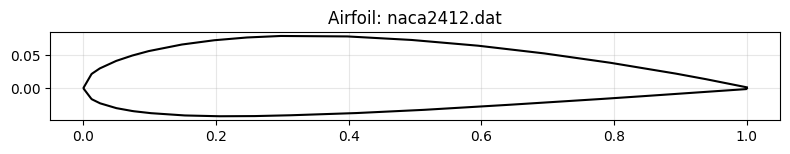

In [4]:
# ═══════════════════════════════════════════════════════════════
#  CELL 4 — Load Airfoil Geometry
# ═══════════════════════════════════════════════════════════════

from pathlib import Path

if not Path(AIRFOIL_PATH).exists():
    raise FileNotFoundError(
        f"AIRFOIL_PATH does not exist: {AIRFOIL_PATH}\n"
        "Set AIRFOIL_PATH in Cell 3 to your uploaded .dat file."
    )

air = AirfoilGeometry(AIRFOIL_PATH, n_boundary=1200)
print(f'Boundary points : {air.boundary.shape[0]}')
print(f'Chord extent    : x=[{air.boundary[:,0].min():.3f}, {air.boundary[:,0].max():.3f}]')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(air.boundary[:, 0], air.boundary[:, 1], 'k-', lw=1.5)
ax.set_aspect('equal')
ax.set_title(f'Airfoil: {os.path.basename(AIRFOIL_PATH)}')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'airfoil_geometry.png'), dpi=160)
plt.show()

In [5]:
# ═══════════════════════════════════════════════════════════════
#  CELL 5 — Build PINN surrogate
# ═══════════════════════════════════════════════════════════════

import torch
import os

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'DEVICE = {DEVICE}')

surrogate = PINN(
    in_dim=5, out_dim=4,
    hidden_dim=50, num_hidden_layers=20,
    activation='silu',
).to(DEVICE)

# Count parameters
n_params = sum(p.numel() for p in surrogate.parameters())
print(f'PINN parameters : {n_params:,}')

# Optional warm-start from existing checkpoint
if RESUME_CHECKPOINT and os.path.exists(RESUME_CHECKPOINT):
    surrogate = load_checkpoint(RESUME_CHECKPOINT, device=DEVICE)
    surrogate = surrogate.to(DEVICE)
    print(f'Warm-started from: {RESUME_CHECKPOINT}')
else:
    print('Training from scratch (random init)')

DEVICE = cuda
PINN parameters : 49,954
Training from scratch (random init)


In [7]:
# ═══════════════════════════════════════════════════════════════
#  CELL 6 — Train Surrogate over alpha range
# ═══════════════════════════════════════════════════════════════

import time
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

t0 = time.time()
print(f'Starting surrogate training for {TOTAL_STEPS} Adam steps...')
print(f'alpha range = ({ALPHA_MIN}°, {ALPHA_MAX}°)  |  Re = {RE_PHYS:.2e}  |  device = {DEVICE}')
print('-' * 60)

surrogate = train(
    model=surrogate,
    airfoil=air,
    alpha=(ALPHA_MIN, ALPHA_MAX),
    Re=RE_PHYS,

    N_int=4000,
    N_near=6000,
    N_wake=1500,
    N_airfoil=1200,
    N_inlet=800,
    N_outlet=800,
    N_top=600,
    N_bot=600,

    adam_steps=TOTAL_STEPS,
    lr_adam=5e-4,
    lbfgs_steps=0,

    adaptive_every=10**9,   # disable adaptive sampler for now
    print_every=max(10, TOTAL_STEPS // 10),
    save_every=10**9,
    out_dir=OUT_DIR,
    device=DEVICE,
)

elapsed = time.time() - t0
print('-' * 60)
print(f'Training complete in {elapsed:.1f} s')

Starting surrogate training for 2000 Adam steps...
alpha range = (0.0°, 10.0°)  |  Re = 1.00e+06  |  device = cuda
------------------------------------------------------------
Normalisation set from 12513 sample points.

Phase 1: Adam  (2000 steps, lr 5.0e-04 → 1.0e-05)
  AoA range: [0.0°, 10.0°]  (surrogate mode)
  Re:  1.0e+06  (single-condition)

step   200/2000 | total 1.884e+03 | pde 4.441e-02 | near 4.657e+01 | wall 8.256e+01 | inlet 3.595e-02 | lr 4.88e-04 | t 234s
step   400/2000 | total 1.861e+03 | pde 3.944e-02 | near 1.076e+01 | wall 9.034e+01 | inlet 2.858e-02 | lr 4.53e-04 | t 468s
step   600/2000 | total 1.845e+03 | pde 2.793e-02 | near 2.093e+01 | wall 8.701e+01 | inlet 2.715e-02 | lr 3.99e-04 | t 702s
step   800/2000 | total 1.847e+03 | pde 3.104e-02 | near 2.026e+01 | wall 8.728e+01 | inlet 2.095e-02 | lr 3.31e-04 | t 936s
step  1000/2000 | total 1.865e+03 | pde 2.169e-02 | near 1.677e+01 | wall 8.907e+01 | inlet 1.985e-02 | lr 2.55e-04 | t 1170s
step  1200/2000 | tota

In [10]:
# ═══════════════════════════════════════════════════════════════
#  CELL 7 — Save Checkpoint
# ═══════════════════════════════════════════════════════════════

import os
from network import save_checkpoint

CKPT_OUT = os.path.join(OUT_DIR, 'best_aoa_surrogate.pt')
save_checkpoint(surrogate, CKPT_OUT, step=TOTAL_STEPS)

print(f'Checkpoint saved → {CKPT_OUT}')

size_mb = os.path.getsize(CKPT_OUT) / (1024**2)
print(f'File size       : {size_mb:.2f} MB')

print()
print('Copy this checkpoint to your app:')
print('  aeropinn_app/backend/models/best_aoa_surrogate.pt')

Checkpoint saved → /content/drive/MyDrive/AeroPINN_X/best_aoa_outputs/best_aoa_surrogate.pt
File size       : 0.21 MB

Copy this checkpoint to your app:
  aeropinn_app/backend/models/best_aoa_surrogate.pt


In [13]:
# ═══════════════════════════════════════════════════════════════
#  CELL 7 — Save Checkpoint
# ═══════════════════════════════════════════════════════════════

import os
from network import save_checkpoint

CKPT_OUT = os.path.join(OUT_DIR, 'best_aoa_surrogate.pt')
save_checkpoint(surrogate, CKPT_OUT, step=TOTAL_STEPS)

print(f'Checkpoint saved → {CKPT_OUT}')

size_mb = os.path.getsize(CKPT_OUT) / (1024**2)
print(f'File size       : {size_mb:.2f} MB')

print()
print('Copy this checkpoint to your app:')
print('  aeropinn_app/backend/models/best_aoa_surrogate.pt')

Checkpoint saved → /content/drive/MyDrive/AeroPINN_X/best_aoa_outputs/best_aoa_surrogate.pt
File size       : 0.21 MB

Copy this checkpoint to your app:
  aeropinn_app/backend/models/best_aoa_surrogate.pt


In [17]:
# ═══════════════════════════════════════════════════════════════
#  CELL 8 — AoA Sweep (no re-training)
# ═══════════════════════════════════════════════════════════════

import numpy as np

alphas = np.linspace(ALPHA_MIN, ALPHA_MAX, N_ALPHA).tolist()
print(f'Evaluating at alphas: {[f"{a:.2f}" for a in alphas]}')

sweep = {
    "alpha": [],
    "CL": [],
    "CD": [],
    "LD": [],
}

for a in alphas:
    forces = compute_forces(
        surrogate,
        air,
        float(a),
        RE_PHYS,
        N_wall=801,
        device=DEVICE,
    )
    sweep["alpha"].append(float(a))
    sweep["CL"].append(float(forces["CL"].detach().cpu().item()))
    sweep["CD"].append(float(forces["CD"].detach().cpu().item()))
    sweep["LD"].append(float(forces["LD"].detach().cpu().item()))

print('\nSweep results:')
print(f'{"alpha":>10} {"CL":>10} {"CD":>12} {"L/D":>10}')
print('-' * 46)

for a, cl, cd, ld in zip(sweep['alpha'], sweep['CL'], sweep['CD'], sweep['LD']):
    print(f'{a:10.2f} {cl:10.4f} {cd:12.6f} {ld:10.4f}')

Evaluating at alphas: ['0.00', '1.11', '2.22', '3.33', '4.44', '5.56', '6.67', '7.78', '8.89', '10.00']

Sweep results:
     alpha         CL           CD        L/D
----------------------------------------------
      0.00    -0.0002     0.000173    -1.1874
      1.11    -0.0002     0.000185    -1.1414
      2.22    -0.0002     0.000189    -1.1747
      3.33    -0.0002     0.000185    -1.3043
      4.44    -0.0003     0.000172    -1.5470
      5.56    -0.0003     0.000149    -1.9310
      6.67    -0.0003     0.000117    -2.5590
      7.78    -0.0003     0.000078    -3.6867
      8.89    -0.0002     0.000034    -6.9274
     10.00    -0.0001    -0.000006   -24.1183


In [18]:
# ═══════════════════════════════════════════════════════════════
#  CELL 9 — Apply Objective & Find Best AoA
# ═══════════════════════════════════════════════════════════════

def objective_value(cl, cd, ld, objective):
    if objective == 'CL':    return cl
    if objective == 'CDmin': return -abs(cd)
    return ld   # default: L/D

objectives = [
    objective_value(cl, cd, ld, OBJECTIVE)
    for cl, cd, ld in zip(sweep['CL'], sweep['CD'], sweep['LD'])
]

best_idx   = int(np.argmax(objectives))
best_alpha = alphas[best_idx]
best_cl    = sweep['CL'][best_idx]
best_cd    = sweep['CD'][best_idx]
best_ld    = sweep['LD'][best_idx]
best_obj   = objectives[best_idx]

obj_label = {'LD': 'L/D', 'CL': 'CL', 'CDmin': '−CD'}[OBJECTIVE]

print(f'════════════════════════════════════════')
print(f'  BEST AoA  :  α = {best_alpha:.2f}°')
print(f'  Objective ({obj_label}) = {best_obj:.4f}')
print(f'  CL  = {best_cl:.4f}')
print(f'  CD  = {best_cd:.6f}')
print(f'  L/D = {best_ld:.4f}')
print(f'  Re  = {RE_PHYS:.2e}')
print(f'════════════════════════════════════════')

════════════════════════════════════════
  BEST AoA  :  α = 1.11°
  Objective (L/D) = -1.1414
  CL  = -0.0002
  CD  = 0.000185
  L/D = -1.1414
  Re  = 1.00e+06
════════════════════════════════════════


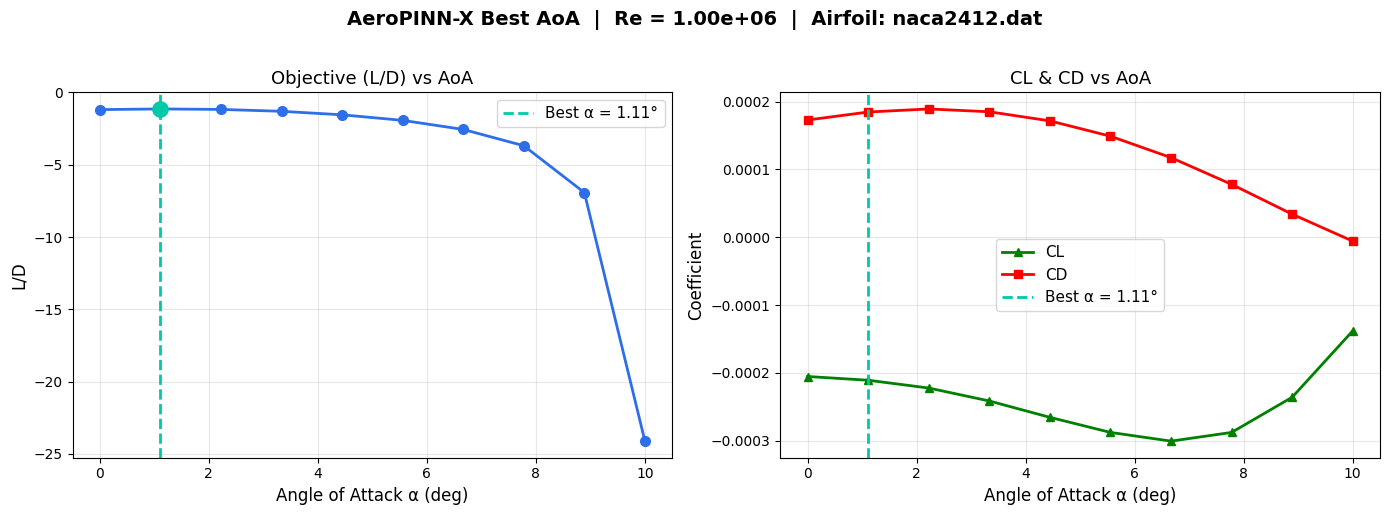

Chart saved → /content/drive/MyDrive/AeroPINN_X/best_aoa_outputs/best_aoa_chart.png


In [19]:
# ═══════════════════════════════════════════════════════════════
#  CELL 10 — Plot: Objective vs AoA
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Objective vs AoA ────────────────────────────────────
axes[0].plot(alphas, objectives, 'o-', color='#2D6FE8', lw=2, ms=7)
axes[0].axvline(best_alpha, color='#00C9A7', lw=2, ls='--',
                label=f'Best α = {best_alpha:.2f}°')
axes[0].scatter([best_alpha], [best_obj], color='#00C9A7', s=120, zorder=5)
axes[0].set_xlabel('Angle of Attack α (deg)', fontsize=12)
axes[0].set_ylabel(obj_label, fontsize=12)
axes[0].set_title(f'Objective ({obj_label}) vs AoA', fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# ── Right: CL & CD vs AoA ────────────────────────────────────
axes[1].plot(alphas, sweep['CL'], 'g^-', label='CL', lw=2)
axes[1].plot(alphas, sweep['CD'], 'rs-', label='CD', lw=2)
axes[1].axvline(best_alpha, color='#00C9A7', lw=2, ls='--',
                label=f'Best α = {best_alpha:.2f}°')
axes[1].set_xlabel('Angle of Attack α (deg)', fontsize=12)
axes[1].set_ylabel('Coefficient', fontsize=12)
axes[1].set_title('CL & CD vs AoA', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'AeroPINN-X Best AoA  |  Re = {RE_PHYS:.2e}  |  Airfoil: {os.path.basename(AIRFOIL_PATH)}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
chart_path = os.path.join(OUT_DIR, 'best_aoa_chart.png')
plt.savefig(chart_path, dpi=160, bbox_inches='tight')
plt.show()
print(f'Chart saved → {chart_path}')

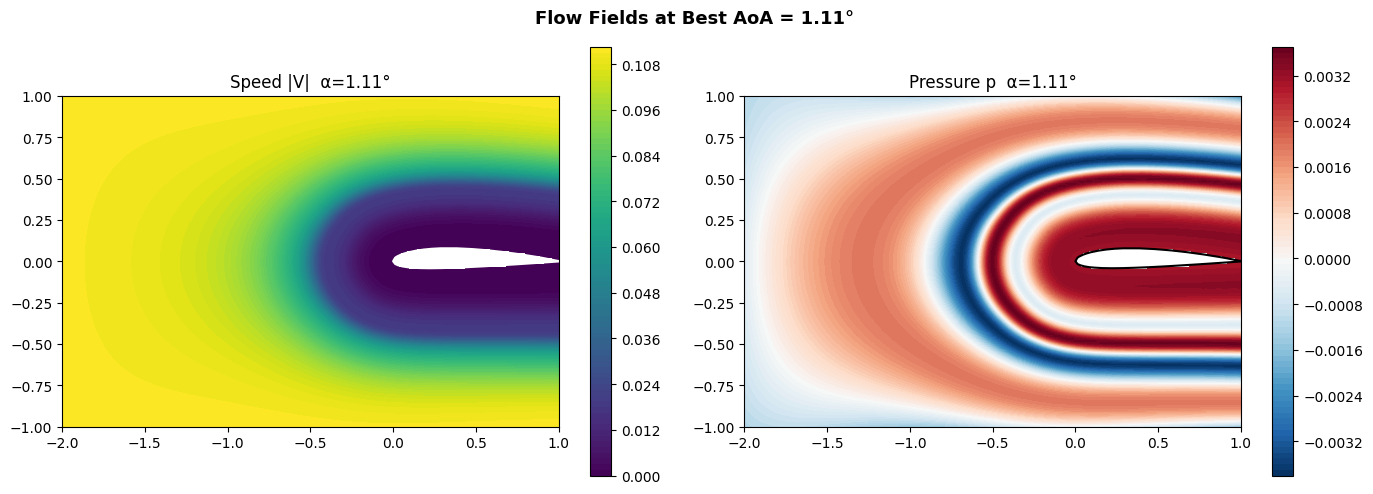

Flow fields saved → /content/drive/MyDrive/AeroPINN_X/best_aoa_outputs/flow_at_best_aoa.png


In [20]:
# ═══════════════════════════════════════════════════════════════
#  CELL 11 — Flow Field at Best AoA (optional visual)
# ═══════════════════════════════════════════════════════════════

import math
from matplotlib.path import Path as MplPath

def build_x_input(pts_xy, alpha_deg, Re_phys, airfoil, device):
    N       = pts_xy.shape[0]
    d       = airfoil.distance(pts_xy).astype(np.float32).reshape(-1, 1)
    alp     = np.full((N, 1), math.radians(alpha_deg), dtype=np.float32)
    relog   = np.full((N, 1), math.log10(Re_phys), dtype=np.float32)
    x_in    = np.concatenate([pts_xy.astype(np.float32), alp, d, relog], axis=1)
    return torch.from_numpy(x_in).to(device)

# Build grid
xs = np.linspace(-2.0, 1.0, 240)
ys = np.linspace(-1.0, 1.0, 140)
X, Y   = np.meshgrid(xs, ys)
pts    = np.stack([X.ravel(), Y.ravel()], axis=1)
xt     = build_x_input(pts, best_alpha, RE_PHYS, air, DEVICE)

with torch.no_grad():
    y_pred = surrogate(xt)

u_grid = y_pred[:, 0].cpu().numpy().reshape(Y.shape)
p_grid = y_pred[:, 2].cpu().numpy().reshape(Y.shape)
speed  = np.sqrt(u_grid**2 + y_pred[:, 1].cpu().numpy().reshape(Y.shape)**2)

# Mask airfoil interior
boundary = air.boundary
inside   = MplPath(boundary).contains_points(pts).reshape(Y.shape)
speed_plot = speed.copy(); speed_plot[inside] = np.nan
p_plot     = p_grid.copy(); p_plot[inside]     = np.nan

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cf0 = axes[0].contourf(X, Y, speed_plot, levels=80, cmap='viridis')
fig.colorbar(cf0, ax=axes[0])
axes[0].plot(boundary[:, 0], boundary[:, 1], 'w-', lw=1.5)
axes[0].set_aspect('equal'); axes[0].set_title(f'Speed |V|  α={best_alpha:.2f}°')

cf1 = axes[1].contourf(X, Y, p_plot, levels=80, cmap='RdBu_r')
fig.colorbar(cf1, ax=axes[1])
axes[1].plot(boundary[:, 0], boundary[:, 1], 'k-', lw=1.5)
axes[1].set_aspect('equal'); axes[1].set_title(f'Pressure p  α={best_alpha:.2f}°')

plt.suptitle(f'Flow Fields at Best AoA = {best_alpha:.2f}°', fontsize=13, fontweight='bold')
plt.tight_layout()
flow_path = os.path.join(OUT_DIR, 'flow_at_best_aoa.png')
plt.savefig(flow_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Flow fields saved → {flow_path}')

In [21]:
# ═══════════════════════════════════════════════════════════════
#  CELL 12 — Download Checkpoint (Colab only)
# ═══════════════════════════════════════════════════════════════

if IN_COLAB:
    from google.colab import files
    print('Downloading checkpoint…')
    files.download(CKPT_OUT)
    print('Also downloading chart…')
    files.download(chart_path)
else:
    print(f'Checkpoint is at: {CKPT_OUT}')
    print()
    print('Copy it to your app backend:')
    print(f'  cp "{CKPT_OUT}" aeropinn_app/backend/models/best_aoa_surrogate.pt')
    print()
    print('Then set in aeropinn_app/backend/.env:')
    print('  MODEL_CHECKPOINT=models/best_aoa_surrogate.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Also downloading chart…


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [22]:
# ═══════════════════════════════════════════════════════════════
#  CELL 13 — Summary Table
# ═══════════════════════════════════════════════════════════════

import pandas as pd

df = pd.DataFrame({
    'alpha (deg)': [round(a, 2) for a in alphas],
    'CL':          [round(c, 6) for c in sweep['CL']],
    'CD':          [round(c, 8) for c in sweep['CD']],
    'L/D':         [round(l, 4) for l in sweep['LD']],
    f'Obj ({obj_label})': [round(o, 6) for o in objectives],
    'Best?':       ['★' if abs(a - best_alpha) < 1e-6 else '' for a in alphas],
})

print(df.to_string(index=False))

csv_path = os.path.join(OUT_DIR, 'best_aoa_results.csv')
df.to_csv(csv_path, index=False)
print(f'\nResults saved → {csv_path}')

 alpha (deg)        CL        CD      L/D  Obj (L/D) Best?
        0.00 -0.000205  0.000173  -1.1874  -1.187377      
        1.11 -0.000211  0.000185  -1.1414  -1.141387     ★
        2.22 -0.000222  0.000189  -1.1747  -1.174735      
        3.33 -0.000241  0.000185  -1.3043  -1.304276      
        4.44 -0.000266  0.000172  -1.5470  -1.546978      
        5.56 -0.000288  0.000149  -1.9310  -1.930979      
        6.67 -0.000301  0.000117  -2.5590  -2.559040      
        7.78 -0.000288  0.000078  -3.6867  -3.686662      
        8.89 -0.000236  0.000034  -6.9274  -6.927428      
       10.00 -0.000138 -0.000006 -24.1183 -24.118313      

Results saved → /content/drive/MyDrive/AeroPINN_X/best_aoa_outputs/best_aoa_results.csv
